# Segment Anything 3


In [1]:
!pip install -q --upgrade "transformers>=4.57.0" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 52.1 MB/s eta 0:00:00


In [ ]:
import os
import torch
from huggingface_hub import login

Token = "TOKEN"
Device = "cuda" if torch.cuda.is_available() else "cpu"

try:
    login(token=Token, add_to_git_credential=False)
    print("Login successful.")
except Exception as e:
    print(f"Authentication note: {e}")

Login successful.


In [3]:
from transformers import (
    Sam3Model, Sam3Processor
)

def load_models():
    global image_model, image_processor

    if "image_model" not in globals():
        print(f"Loading SAM 3 (Image) onto {Device}...")
        image_model = Sam3Model.from_pretrained("facebook/sam3").to(Device).eval()
        image_processor = Sam3Processor.from_pretrained("facebook/sam3")

    print("Model ready for inference.")

load_models()

Loading SAM 3 (Image) onto cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Model ready for inference.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def plot_results(image_np, masks, boxes, scores, prompt):
    n = len(masks)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    rng = np.random.default_rng(0)

    # Panel 1: Original
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Panel 2: Overlay
    axes[1].imshow(image_np)
    for i in range(n):
        m = masks[i].cpu().numpy().astype(bool)
        color = rng.random(3)
        overlay = np.zeros((*m.shape, 4))
        overlay[m] = [*color, 0.5]
        axes[1].imshow(overlay)

        x0, y0, x1, y1 = boxes[i].cpu().numpy()
        axes[1].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor=color, linewidth=2))
        axes[1].text(x0, max(y0 - 5, 0), f"{scores[i]:.2f}",
                     color="white", fontsize=10, bbox=dict(facecolor=color, alpha=0.7, pad=1))

    axes[1].set_title(f"Overlay: '{prompt}' ({n} found)")
    axes[1].axis("off")

    # Panel 3: Binary Mask
    combined = masks.cpu().numpy().any(axis=0) if n > 0 else np.zeros(image_np.shape[:2])
    axes[2].imshow(combined, cmap="gray")
    axes[2].set_title("All Masks")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

def segment_image(image_path, text_prompt, score_threshold=0.5, out_dir="sam3_outputs"):
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    inputs = image_processor(images=image, text=text_prompt, return_tensors="pt").to(Device)
    with torch.no_grad():
        outputs = image_model(**inputs)

    results = image_processor.post_process_instance_segmentation(
        outputs,
        threshold=score_threshold,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    masks, boxes, scores = results["masks"], results["boxes"], results["scores"]
    plot_results(img_np, masks, boxes, scores, text_prompt)

    # Save outputs
    os.makedirs(out_dir, exist_ok=True)
    if len(masks) > 0:
        combined_mask = masks.cpu().numpy().any(axis=0)
        rgba = np.dstack([img_np, (combined_mask * 255).astype(np.uint8)])
        Image.fromarray(rgba, mode="RGBA").save(os.path.join(out_dir, "cutout.png"))
    print(f"Found {len(masks)} objects. Results saved to: {out_dir}")

def segment(file_path, text_prompt, score_threshold=0.5):
    ext = os.path.splitext(file_path)[1].lower()
    segment_image(file_path, text_prompt, score_threshold)

Upload an image (jpg/png/...)


Saving Maine_Coon_193_jpg.rf.a5ccc142bf507c3fbee745fef4309fa3.jpg to Maine_Coon_193_jpg.rf.a5ccc142bf507c3fbee745fef4309fa3.jpg
What would you like to segment? (e.g. 'cat', 'red car'): cat


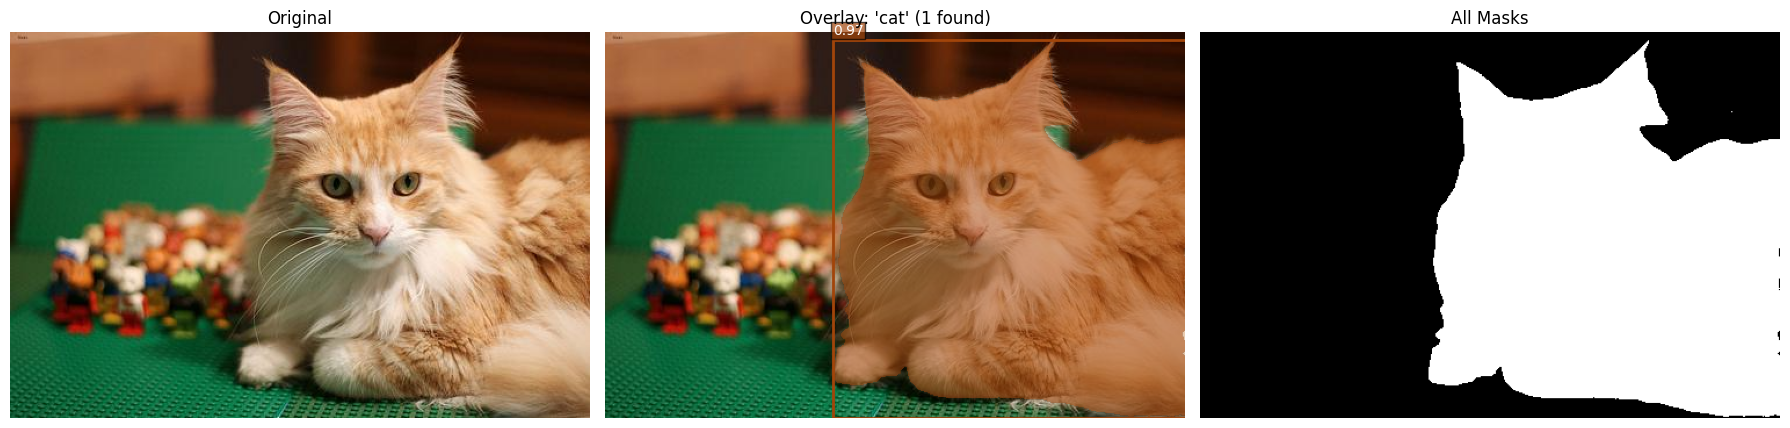

Found 1 objects. Results saved to: sam3_outputs


/tmp/ipykernel_3356/1328018456.py:65: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(rgba, mode="RGBA").save(os.path.join(out_dir, "cutout.png"))


In [7]:
from google.colab import files

print("Upload an image: ")
uploaded = files.upload()
file_path = next(iter(uploaded))

txt_prmpt = input("What would you like to segment?").strip()
threshold = 0.5

segment(file_path, txt_prmpt, threshold)
